In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

In [19]:
API_KEY = "d7bb8df820970bcd809513ffc6744c44" 
CITY = "Nagpur"
URL = f"http://api.openweathermap.org/data/2.5/forecast?q={CITY}&appid={API_KEY}&units=metric"

In [21]:
response = requests.get(URL)
data = response.json()

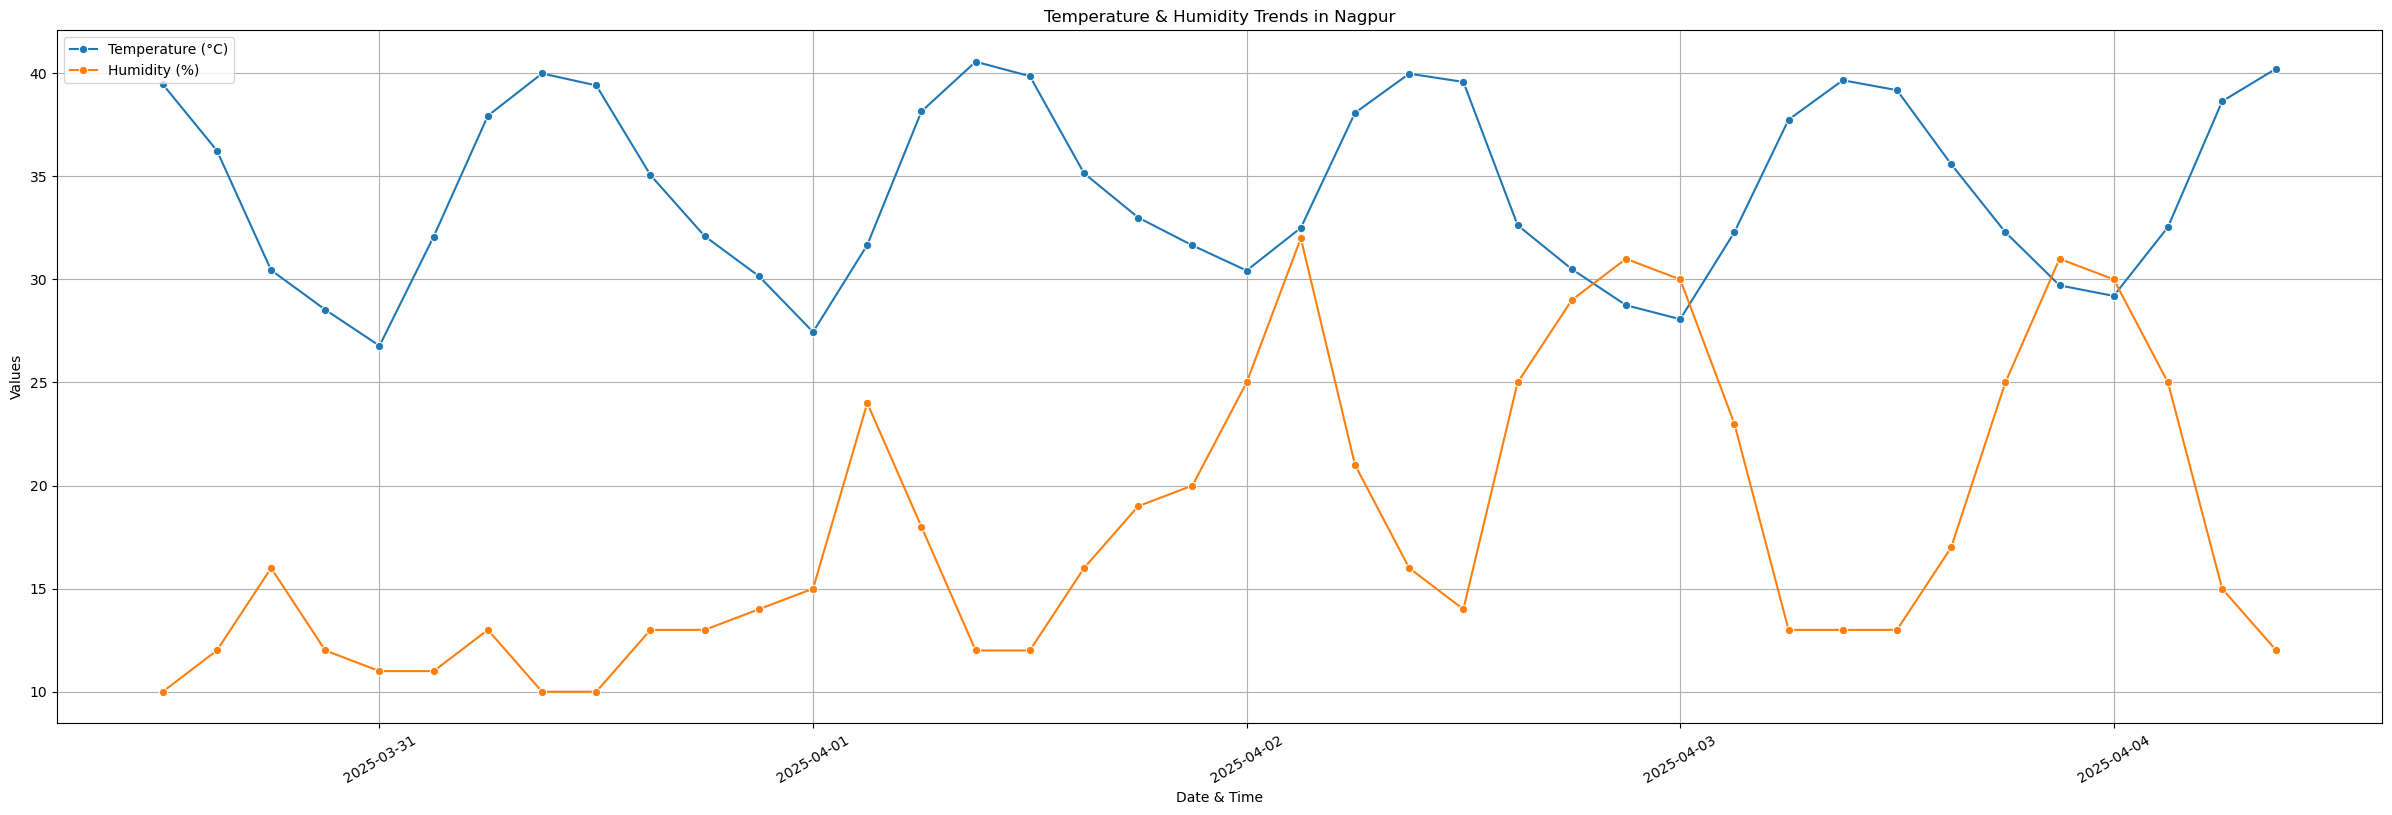

Data saved as weather_data.csv and visualization saved as weather_dashboard.png


In [25]:
if "list"in data:
    weather_list = data["list"]
    df = pd.DataFrame({
    "Date": [entry["dt_txt"] for entry in weather_list],
    "Temperature": [entry["main"]["temp"] for entry in weather_list],
    "Humidity": [entry["main"]["humidity"] for entry in weather_list]
    })
    df["Date"] = pd.to_datetime(df["Date"])
    plt.figure(figsize=(30,9))
    sns.lineplot(x=df["Date"], y=df["Temperature"], label="Temperature (°C)", marker="o")
    sns.lineplot(x=df["Date"], y=df["Humidity"], label="Humidity (%)", marker="o")
    plt.xticks(rotation=30)
    plt.xlabel("Date & Time")
    plt.ylabel("Values")
    plt.title("Temperature & Humidity Trends in Nagpur")
    plt.legend()
    plt.grid(True)
    plt.savefig("weather_dashboard.png")
    plt.show()
    df.to_csv("weather_data.csv", index=False)
    print("Data saved as weather_data.csv and visualization saved as weather_dashboard.png")
else:
    print("Error:", data.get("message", "Unknown error"))
  